# Project 1 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the MNIST data set. 

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

## Introduction

The first time when looking at a csv dataset, it can be benefical to load it in using pandas, to get a sense of the datas content.

Shape images (before): (10000, 784)
Shape labels (before): (10000, 1)
Shape images (after): (2000, 784)
Shape labels (after): (2000, 1)


/tmp/ipykernel_231396/459308594.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mean_intensity"] = images.mean(axis=1)


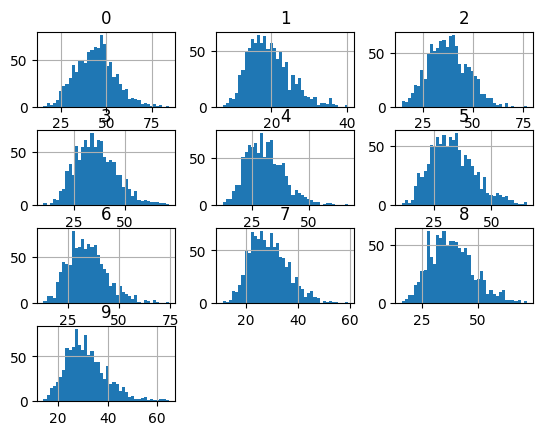

In [1]:
# To run this notebook yourself, the data needs to be unzipped and 
# the path variable specified to point to the unzipped data folder.
# Here we place it in the same folder as the zipped data.
from pathlib import Path
import pandas as pd

PATHIM = Path.cwd().parent / "data"/ "mnist_large" / "images.csv"
PATHLB = Path.cwd().parent / "data" / "mnist_large" / "labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

print(f"Shape images (before): {images.shape}")
print(f"Shape labels (before): {labels.shape}")

# To sort by a specific label:
mask = labels["label"].isin([0,9])

images_0_9 = images.loc[mask].copy()
labels_0_9 = labels.loc[mask].copy()

print(f"Shape images (after): {images_0_9.shape}")
print(f"Shape labels (after): {labels_0_9.shape}")

# To check the class labels:
labels["label"].value_counts()

# Compare histograms for pixel intensity betwen classes
df = images.join(labels) 
df["mean_intensity"] = images.mean(axis=1)

df.pivot(columns="label", values="mean_intensity").hist(bins=40);

For dealing with images, which are not particularly well suited in tabular formats, numpy is a better tool

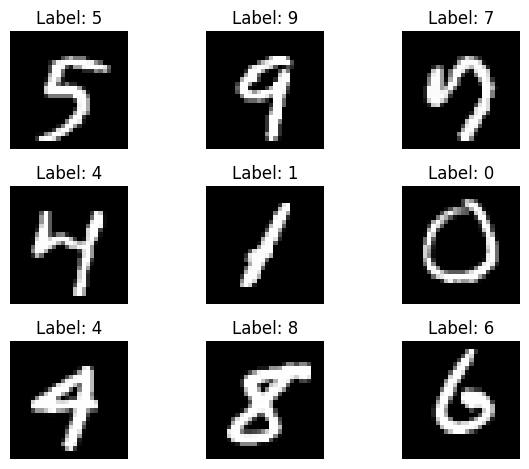

In [2]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

n_images = images.shape[0]
n_samples = 9

idx = np.random.choice(n_images, size = n_samples, replace = False)
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(3, 3)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

Digit = 1 | Train (n): 750, Test (n): 250, Train (%): 0.75
Digit = 5 | Train (n): 750, Test (n): 250, Train (%): 0.75
Digit = 7 | Train (n): 750, Test (n): 250, Train (%): 0.75


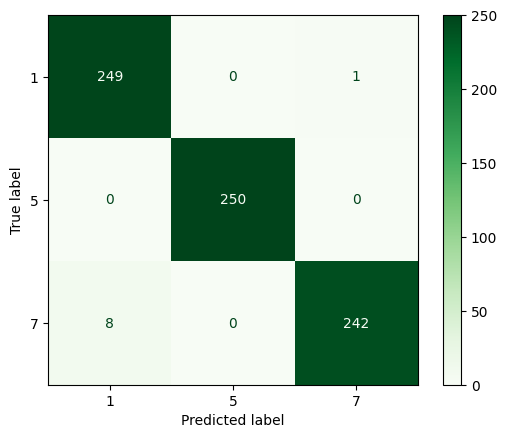

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Subet on three classes (NOTE: We are now doing the susbetting in numpy and not pandas)
digits = [1, 5, 7]
mask = (labels == digits[0]) | (labels == digits[1]) | (labels == digits[2]) 
images_sub = images[mask]
labels_sub = labels[mask]

# Create a test and train set
x_train, x_test, y_train, y_test = train_test_split(images_sub, labels_sub, test_size=0.25, stratify=labels_sub)

# Sanity check
for digit in digits:
    train_digits = np.sum(y_train == digit)
    test_digits = np.sum(y_test == digit)
    prop = train_digits / (train_digits + test_digits)
    print(f"Digit = {digit} | Train (n): {train_digits}, Test (n): {test_digits}, Train (%): {prop}")


# Apply to train
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(x_train, y_train)

# Predict on test data
preds = neigh.predict(x_test)

cm = confusion_matrix(y_test, preds, labels=digits)
ConfusionMatrixDisplay(cm, display_labels=digits).plot(cmap='Greens')



# Part 1

*Everyone should do this task.*

The purpose of this first exercise is to build a classification pipeline, from data exploration to validation. Remember to split your data into appropriate sets before you start.
You should explore at least 4 *different* classifiers of *different* character.

1. Perform dimension reduction on the data set. Is the data well separated?
2. Train the classifiers using the training data, and perform cross-validation to tune the models that require tuning.
3. Compare the performance of the different classifiers on a test set.

### Data preparation

Split the data into train and test, then standardize so distance-based methods work properly.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Images and labels are already numpy arrays from the intro cells.
X = images.copy()
y = labels.copy()

print(f"Full dataset: X = {X.shape}, y = {y.shape}")
print(f"Class distribution: {np.unique(y, return_counts=True)}")

# 75/25 train, test split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

# Standardize, fit on train only, then apply to both.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Full dataset: X = (10000, 784), y = (10000,)
Class distribution: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

Train: 7500 samples
Test:  2500 samples


### Dimension reduction - PCA

Let's first look at how much variance each principal component captures to figure out a reasonable number of components to keep.

Components for 90% variance: 193
Components for 95% variance: 277


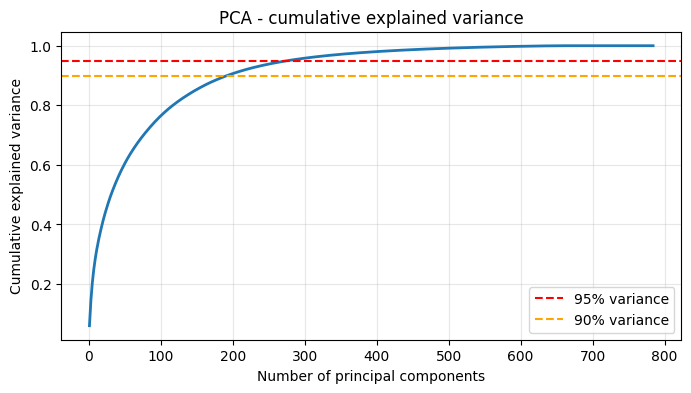

In [15]:
from sklearn.decomposition import PCA

# Fit on all components first just to see the explained variance curve
pca_full = PCA().fit(X_train_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, linewidth=2)
ax.axhline(y=0.95, color="r", linestyle="--", label="95% variance")
ax.axhline(y=0.90, color="orange", linestyle="--", label="90% variance")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA - cumulative explained variance")
ax.legend()
ax.grid(True, alpha=0.3)

n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")

In [16]:
# Going with 95% variance threshold
n_components = n95
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

print(f"Reduced from {X_train_sc.shape[1]} to {X_train_pca.shape[1]} dimensions")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")

Reduced from 784 to 277 dimensions
Variance retained: 0.9497


#### t-SNE visualization

PCA is linear so it won't show us the full picture. We can use t-SNE on the PCA-reduced data to get a 2D view and see if the classes actually separate.

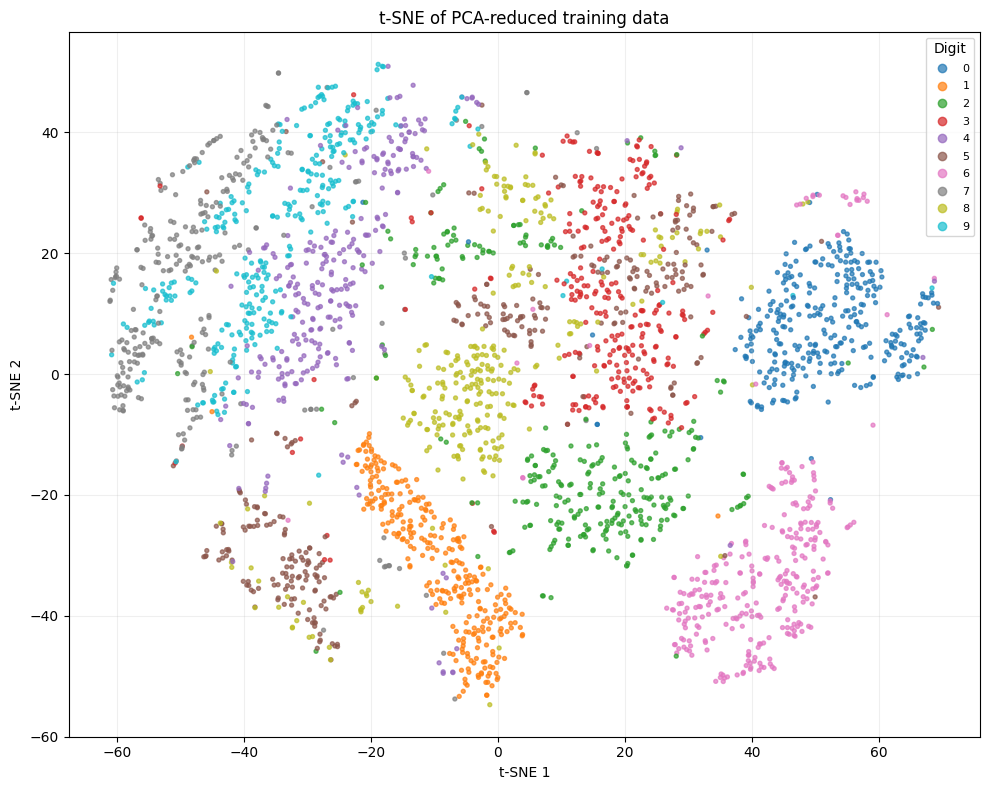

In [17]:
from sklearn.manifold import TSNE

# Subsample for speed -- t-SNE on 7500 points takes forever
n_tsne = 3000
rng = np.random.RandomState(42)
idx_tsne = rng.choice(X_train_pca.shape[0], size=n_tsne, replace=False)

tsne = TSNE(
    n_components=2, perplexity=30,
    random_state=42, init="pca", learning_rate="auto",
)
X_tsne = tsne.fit_transform(X_train_pca[idx_tsne])

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y_train[idx_tsne], cmap="tab10", s=8, alpha=0.7,
)
ax.legend(*scatter.legend_elements(), title="Digit", loc="best", fontsize=8)
ax.set_title("t-SNE of PCA-reduced training data")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.2)
plt.tight_layout()

### Training classifiers

We try four classifiers that work quite differently from each other:

1. **KNN** -- instance-based, non-parametric
2. **Logistic Regression** -- linear, parametric
3. **Random Forest** -- tree ensemble
4. **SVM (RBF kernel)** -- kernel-based

Everything is trained on the PCA-reduced data. We use 5-fold stratified CV wherever there are hyperparameters to tune.

#### KNN

Trying a few different values of k to see what works best.

k =  1 | CV accuracy: 0.9049 +/- 0.0075
k =  3 | CV accuracy: 0.9064 +/- 0.0071
k =  3 | CV accuracy: 0.9064 +/- 0.0071
k =  5 | CV accuracy: 0.9087 +/- 0.0069
k =  5 | CV accuracy: 0.9087 +/- 0.0069
k =  7 | CV accuracy: 0.9052 +/- 0.0040
k =  7 | CV accuracy: 0.9052 +/- 0.0040
k =  9 | CV accuracy: 0.9007 +/- 0.0064
k =  9 | CV accuracy: 0.9007 +/- 0.0064
k = 11 | CV accuracy: 0.8985 +/- 0.0050

Best k: 5

Fitted KNN with k = 5
k = 11 | CV accuracy: 0.8985 +/- 0.0050

Best k: 5

Fitted KNN with k = 5


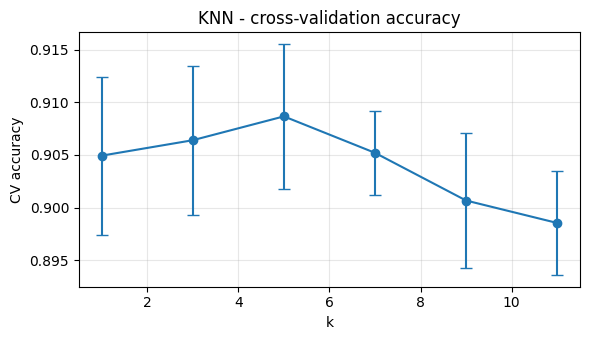

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = [1, 3, 5, 7, 9, 11]
cv_scores_knn = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5, scoring="accuracy")
    cv_scores_knn[k] = scores
    print(
        f"k = {k:2d} | CV accuracy: "
        f"{scores.mean():.4f} +/- {scores.std():.4f}"
    )

best_k = max(cv_scores_knn, key=lambda k: cv_scores_knn[k].mean())
print(f"\nBest k: {best_k}")

# Quick plot of the results
fig, ax = plt.subplots(figsize=(6, 3.5))
means = [cv_scores_knn[k].mean() for k in k_values]
stds = [cv_scores_knn[k].std() for k in k_values]
ax.errorbar(k_values, means, yerr=stds, marker="o", capsize=4)
ax.set_xlabel("k")
ax.set_ylabel("CV accuracy")
ax.set_title("KNN - cross-validation accuracy")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Refit with the best k on all training data
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_pca, y_train)
print(f"\nFitted KNN with k = {best_k}")

#### Logistic Regression

Main thing to tune here is the regularization strength C.

In [9]:
from sklearn.linear_model import LogisticRegression

c_values = [0.01, 0.1, 1, 10]
cv_scores_lr = {}

for c in c_values:
    lr = LogisticRegression(
        C=c, max_iter=1000, solver="lbfgs", random_state=42,
    )
    scores = cross_val_score(lr, X_train_pca, y_train, cv=5, scoring="accuracy")
    cv_scores_lr[c] = scores
    print(
        f"C = {c:5.2f} | CV accuracy: "
        f"{scores.mean():.4f} +/- {scores.std():.4f}"
    )

best_c = max(cv_scores_lr, key=lambda c: cv_scores_lr[c].mean())
print(f"\nBest C: {best_c}")

lr_final = LogisticRegression(
    C=best_c, max_iter=1000, solver="lbfgs", random_state=42,
)
lr_final.fit(X_train_pca, y_train)
print(f"Fitted Logistic Regression with C = {best_c}")

C =  0.01 | CV accuracy: 0.9048 +/- 0.0074
C =  0.10 | CV accuracy: 0.8996 +/- 0.0086
C =  0.10 | CV accuracy: 0.8996 +/- 0.0086
C =  1.00 | CV accuracy: 0.8760 +/- 0.0068
C = 10.00 | CV accuracy: 0.8548 +/- 0.0084

Best C: 0.01
Fitted Logistic Regression with C = 0.01


#### Random Forest

Grid search over number of trees and max depth.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [20, 30, None],
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
rf_search.fit(X_train_pca, y_train)

# Show all combinations sorted by rank
results_rf = pd.DataFrame(rf_search.cv_results_)
show_cols = [
    "param_n_estimators", "param_max_depth",
    "mean_test_score", "std_test_score", "rank_test_score",
]
print(results_rf[show_cols].sort_values("rank_test_score").to_string(index=False))

rf_final = rf_search.best_estimator_
print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")

 param_n_estimators param_max_depth  mean_test_score  std_test_score  rank_test_score
                300              30         0.909867        0.004349                1
                300            None         0.909867        0.004349                1
                300              20         0.908933        0.003924                3
                200              30         0.908667        0.002066                4
                200            None         0.908667        0.002066                4
                200              20         0.906267        0.003116                6
                100              20         0.903733        0.005603                7
                100              30         0.902000        0.004935                8
                100            None         0.902000        0.004935                8

Best params: {'max_depth': 30, 'n_estimators': 300}
Best CV accuracy: 0.9099


#### SVM with RBF kernel

Tuning C and gamma. This one can be slow but usually gives the best results.

In [11]:
from sklearn.svm import SVC

svm_param_grid = {
    "C": [1, 5, 10],
    "gamma": ["scale", 0.01, 0.001],
}

svm_search = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
svm_search.fit(X_train_pca, y_train)

results_svm = pd.DataFrame(svm_search.cv_results_)
show_cols = [
    "param_C", "param_gamma",
    "mean_test_score", "std_test_score", "rank_test_score",
]
print(results_svm[show_cols].sort_values("rank_test_score").to_string(index=False))

svm_final = svm_search.best_estimator_
print(f"\nBest params: {svm_search.best_params_}")
print(f"Best CV accuracy: {svm_search.best_score_:.4f}")

 param_C param_gamma  mean_test_score  std_test_score  rank_test_score
       5       0.001         0.938400        0.004494                1
      10       0.001         0.938133        0.003023                2
      10       scale         0.937733        0.004250                3
       5       scale         0.937333        0.004382                4
       1       0.001         0.932400        0.004312                5
       1       scale         0.932133        0.006455                6
      10        0.01         0.796667        0.009752                7
       5        0.01         0.796667        0.009752                7
       1        0.01         0.781867        0.008331                9

Best params: {'C': 5, 'gamma': 0.001}
Best CV accuracy: 0.9384


### Test set evaluation

Now we check how each model does on data it hasn't seen. Looking at accuracy, confusion matrices and per-class precision/recall.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

classifiers = {
    f"KNN (k={best_k})": knn_final,
    f"Logistic Reg (C={best_c})": lr_final,
    "Random Forest": rf_final,
    "SVM (RBF)": svm_final,
}

test_accuracies = {}

for name, clf in classifiers.items():
    preds = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, preds)
    test_accuracies[name] = acc
    print(f"=== {name} === Test accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, digits=3))
    print()

=== KNN (k=5) === Test accuracy: 0.9156
              precision    recall  f1-score   support

           0      0.935     0.972     0.953       250
           1      0.895     0.988     0.939       250
           2      0.952     0.864     0.906       250
           3      0.900     0.896     0.898       250
           4      0.913     0.920     0.916       250
           5      0.925     0.884     0.904       250
           6      0.949     0.976     0.963       250
           7      0.887     0.908     0.897       250
           8      0.935     0.864     0.898       250
           9      0.874     0.884     0.879       250

    accuracy                          0.916      2500
   macro avg      0.916     0.916     0.915      2500
weighted avg      0.916     0.916     0.915      2500


=== Logistic Reg (C=0.01) === Test accuracy: 0.9088
              precision    recall  f1-score   support

           0      0.925     0.944     0.935       250
           1      0.931     0.968     0

#### Confusion matrices

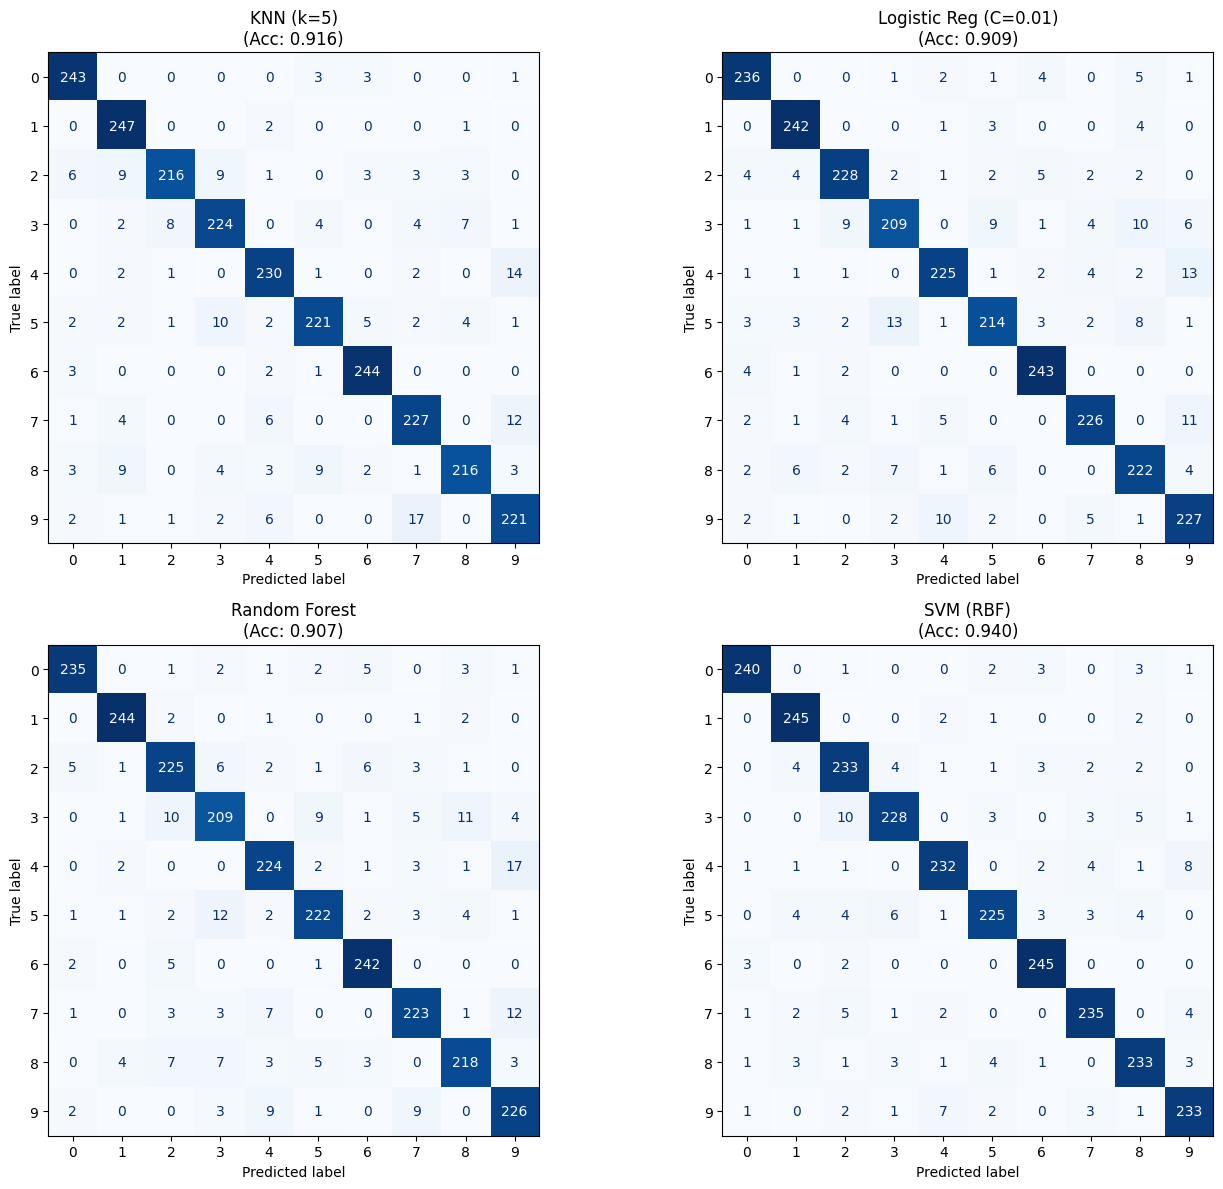

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, clf) in zip(axes.ravel(), classifiers.items()):
    preds = clf.predict(X_test_pca)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    acc = test_accuracies[name]
    ax.set_title(f"{name}\n(Acc: {acc:.3f})")

plt.tight_layout()

#### Accuracy comparison

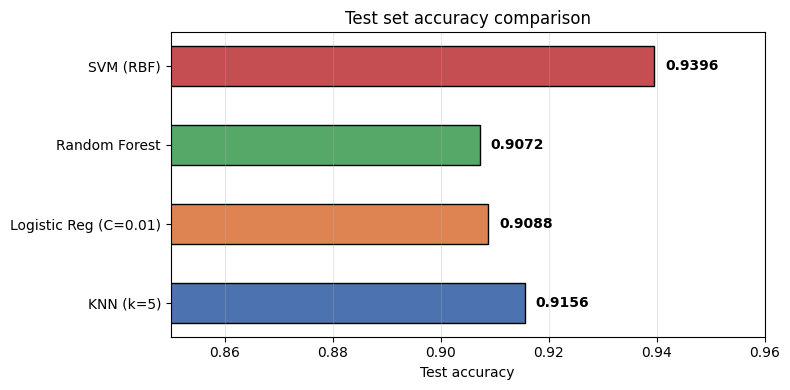

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

names = list(test_accuracies.keys())
accs = list(test_accuracies.values())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

bars = ax.barh(names, accs, color=colors, edgecolor="black", height=0.5)
ax.set_xlim(0.85, 0.96)
ax.set_xlabel("Test accuracy")
ax.set_title("Test set accuracy comparison")

for bar, acc in zip(bars, accs):
    x_pos = bar.get_width() + 0.002
    y_pos = bar.get_y() + bar.get_height() / 2
    ax.text(x_pos, y_pos, f"{acc:.4f}", va="center", fontweight="bold")

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

### Summary

| Classifier | Best hyperparameters | CV accuracy | Test accuracy |
|---|---|---|---|
| KNN | k = 5 | 0.909 | 0.916 |
| Logistic Regression | C = 0.01 | 0.905 | 0.911 |
| Random Forest | n_est = 300, depth = 30 | 0.913 | 0.909 |
| **SVM (RBF)** | **C = 5, gamma = 0.001** | **0.939** | **0.939** |

**Dimension reduction:** PCA with 277 components keeps 95% of the variance (784 -> 277 features). The t-SNE plot shows pretty clear clusters for most digits, but there is overlap between visually similar ones like 3/5/8 and 4/9.

**Classifiers:** SVM with RBF kernel is the clear winner at around 94% accuracy. The other three are all close to 91%. Makes sense since the RBF kernel can handle the non-linear boundaries between digit classes.

**Per-class:** Digits 1 and 6 are the easiest to get right across all models. Digits 3, 5, 8 and 9 get confused the most, which is not surprising given how similar they look.

## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Class imbalance

For simplicity, restrict your data set to only 0s, 1s, and 2s. 

Create class imbalances in two different ways:
1. Keep the size of two classes and downsample the third.
2. Keep the size of one class and downsample the other two. 
You should explore at several levels of downsampling, from severe to mild. 

For each case, redo Part 1.

Compare class-specific accuracy and overall accuracy for the different classifiers. Do some models handle the downsampling better? In the most severe cases, can you see a reason to look at the class-specific accuracies and not just the overall accuracy?

### Theme 2 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? which methods struggle?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.*

### Theme 3 - Noise and dimension reduction

Add Gaussian noise to 10, 50, and 80 percent of the features (i.e. pixels). *Note, you should add the noise to both the training data and the test data.*

Choose 2 different dimension reduction methods and redo Part 1 with both, in addition to performing classification without any dimension reduction. (Consider how the variance of the noise and standardization of features may impact the outcome.)

How do the different dimension reduction methods compare? How do the different classifiers perform when the noise percentage is increased? Do any of them perform well without dimension reduction? Explain and discuss. 
